The product team at a popular bank noticed an uptick in churn and a decline in growth, and they want to find ways to reduce churn and appeal to new customers.

This project goes through cleaning and exploring bank customer data to prepare it for a churn prediction machine learning project.
The dataset contains 10,004 records. 

The objectives:
1. Join & QA the data and remove duplicates
2. Clean the data
3. Explore feature relationships with customer churn
4. Prepare the data for modeling

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### OBJECTIVE 1

In [ ]:
#acc_info = pd.read_excel('https://raw.githubusercontent.com/adrielmolina/portfolio/refs/heads/main/data/Bank_Churn_Messy.xlsx', sheet_name=1)
#cus_info = pd.read_excel('https://raw.githubusercontent.com/adrielmolina/portfolio/refs/heads/main/data/Bank_Churn_Messy.xlsx', sheet_name=0)

acc_info = pd.read_excel('data/Bank_Churn_Messy.xlsx', sheet_name=1)
cus_info = pd.read_excel('data/Bank_Churn_Messy.xlsx', sheet_name=0)

churn = cus_info.merge(acc_info, how='left', on='CustomerId')

churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [5]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


Checking the rows and columns for any duplicates 

In [6]:
# remove the duplicate tenure column and rename the Tenure_x column
churn['Tenure_x'].equals(churn['Tenure_y'])
churn = churn.drop(columns='Tenure_y').rename(columns={'Tenure_x':'Tenure'})

# remove the duplicate records
dup_count = churn.duplicated().sum()
churn = churn.drop_duplicates()
print(dup_count,'duplicate records removed')
churn.info()

4 duplicate records removed
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


### OBJECTIVE 2

Cleaning the values

In [7]:
churn['Geography'].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1655
FRA        1618
Name: count, dtype: int64

In [ ]:
# remove € symbol
churn['Balance'] = churn['Balance'].str.replace('€','').astype(float)
churn['EstimatedSalary'] = churn['EstimatedSalary'].str.replace('€','').astype(float)

# standardize country name
churn['Geography'] = churn['Geography'].str.replace('FRA','France')
churn['Geography'] = churn['Geography'].str.replace('French','France')

# convert data types and fill NA with the median age value
churn['Age'] = churn['Age'].fillna(churn['Age'].median()).astype(int)

# churn.head(10)
churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 1.1+ MB


Check for missing values

In [ ]:
churn[churn.isna().any(axis=1)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,37,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,NaN,674,Spain,Male,37,6,-999999.0,120193.42,1,No,No,0
9390,15756954,NaN,538,France,Female,37,2,-999999.0,0.00,1,Yes,Yes,0


Fill missing values

In [ ]:

categorical_cols = churn.select_dtypes(include='object').columns
numerical_cols = churn.select_dtypes(include=['number']).columns
# categorical_cols
# numerical_cols

churn[categorical_cols] = churn[categorical_cols].fillna('MISSING')
churn[numerical_cols] = churn[numerical_cols].fillna(churn[numerical_cols].median())

#alt method
#churn.fillna(value={'Surname':'MISSING', 'Age':churn['Age'].median()})

churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 1.1+ MB


In [11]:
churn.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,99762.195289,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,60583.863580,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


Clean the unusual numbers in EstimatedSalary and replace with the median value

In [ ]:
churn['EstimatedSalary'] = churn['EstimatedSalary'].replace(-999999.0, churn['EstimatedSalary'].median())


### OBJECTIVE 3

Visualize the data

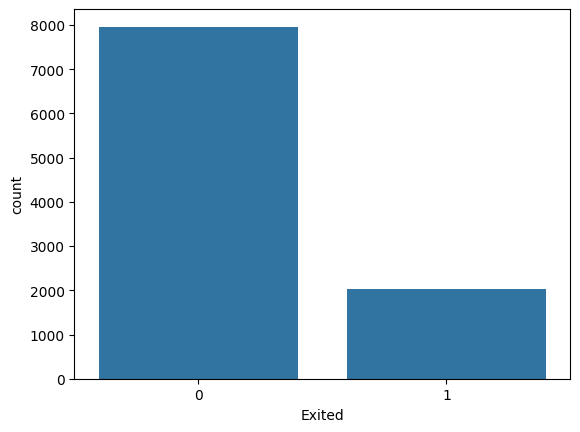

In [ ]:
churner_count = sns.countplot(data=churn, x='Exited')

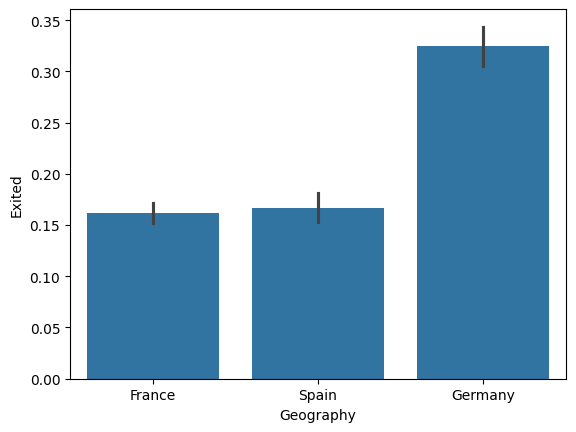

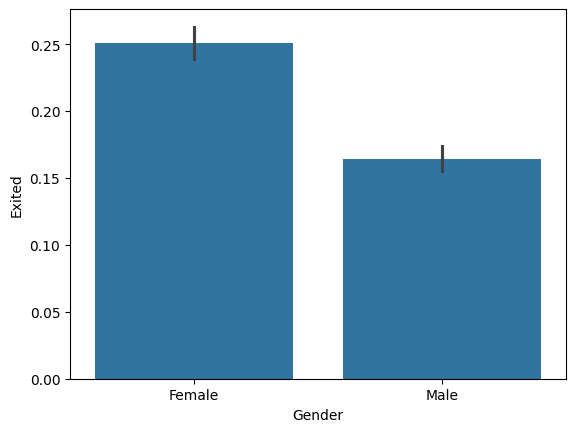

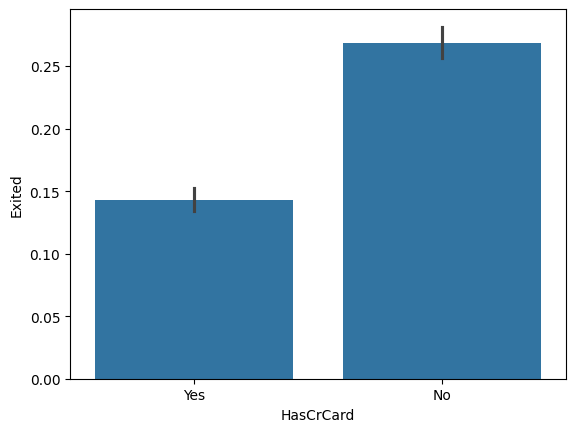

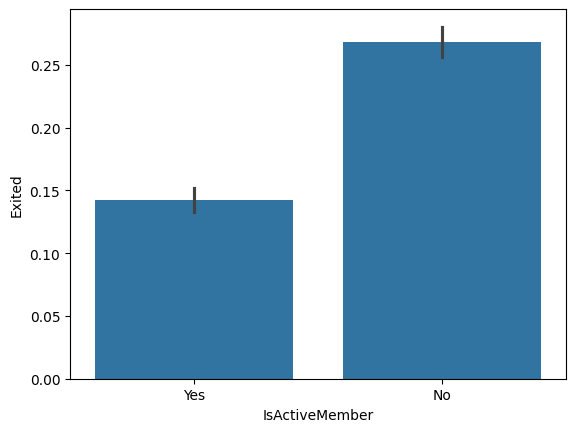

In [14]:
for column in churn.drop('Surname', axis=1).select_dtypes('object'):
    plot = sns.barplot(churn, x=column, y='Exited')
    plt.show()

The geography charts shows Germany has the highest churn rate among 3 countries which the branch should look into. The gender chart shows that majority of the churners are female.

Box plots for numerical fields

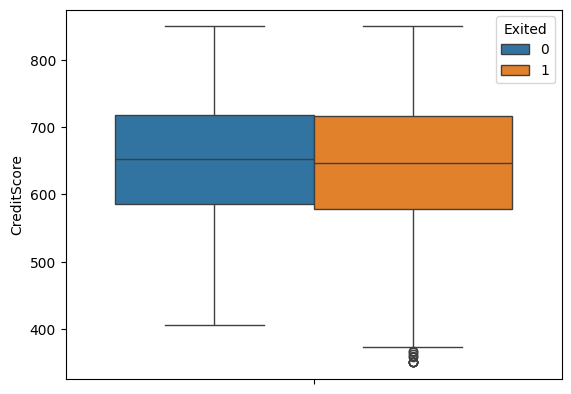

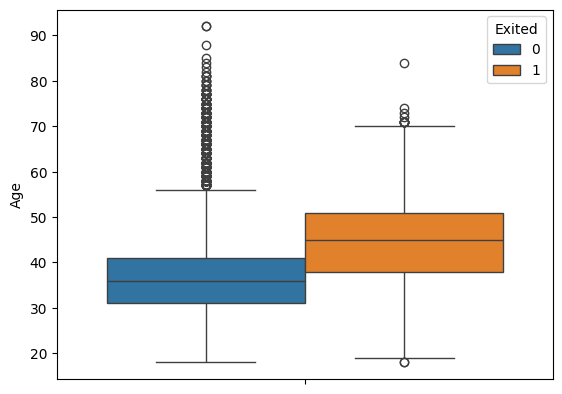

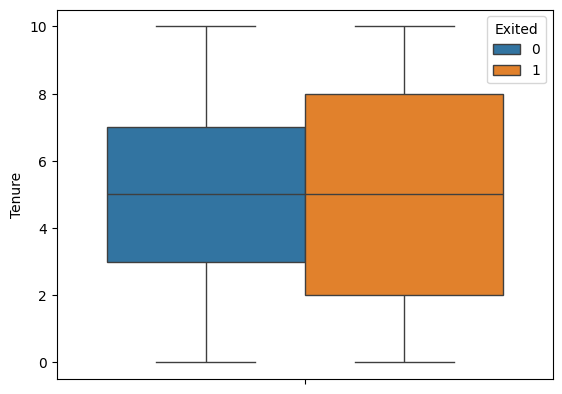

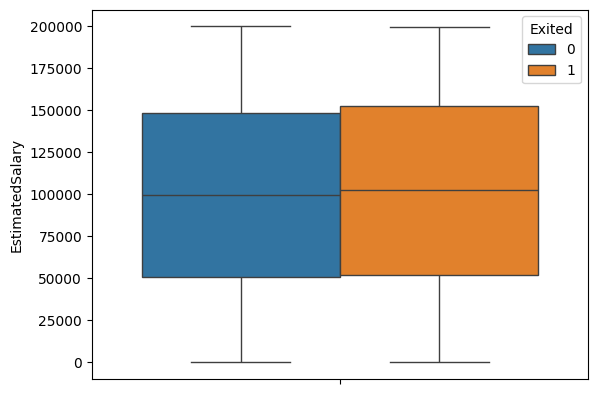

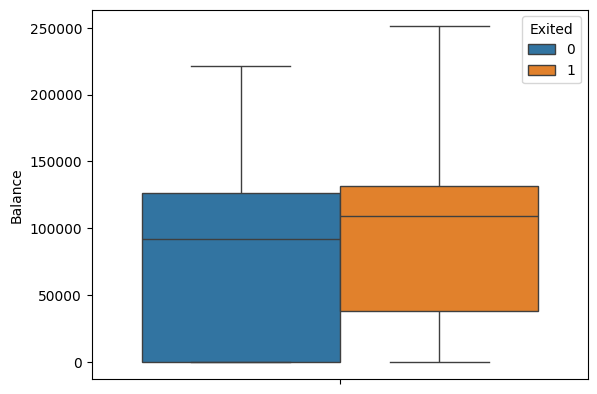

In [15]:
for column in churn.drop(['CustomerId','NumOfProducts','Exited'], axis=1).select_dtypes('number'):
    plot = sns.boxplot(churn, y=column, hue='Exited')
    plt.show()


Histograms for numeric fields

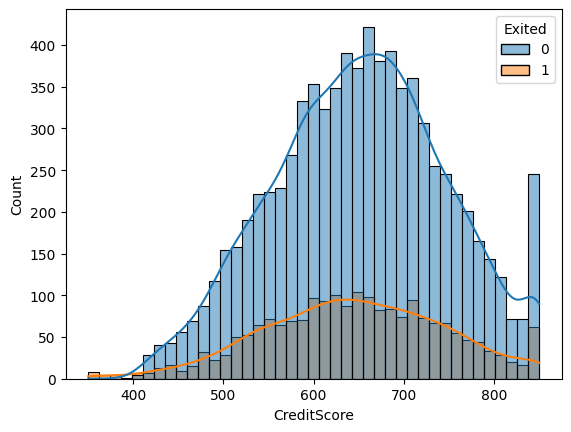

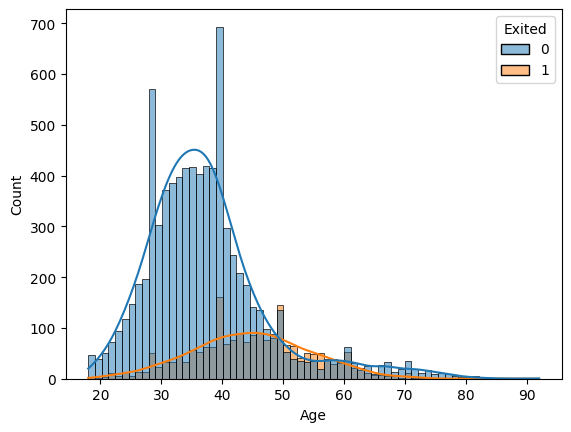

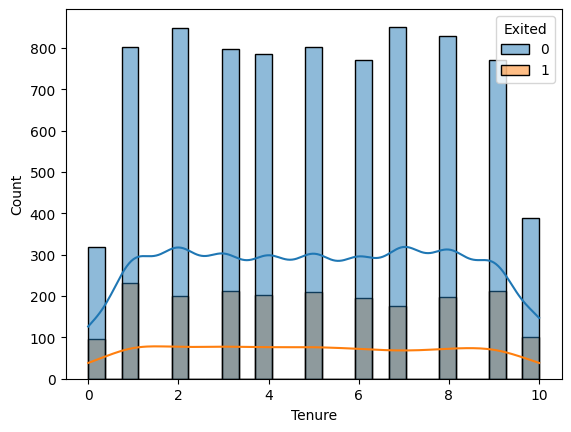

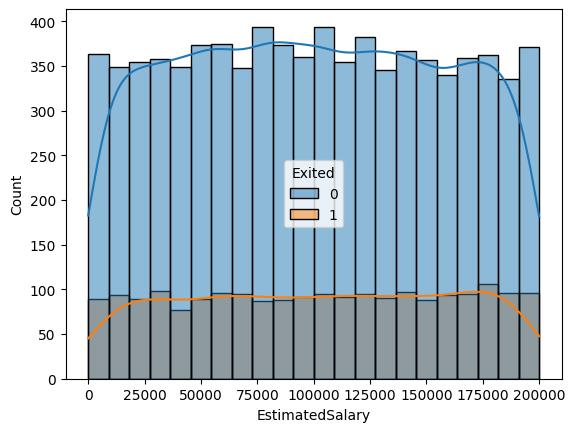

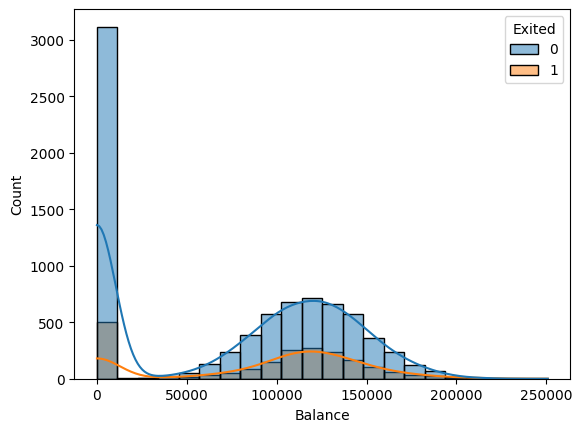

In [16]:
for column in churn.drop(['CustomerId','NumOfProducts','Exited'], axis=1).select_dtypes('number'):
    plot = sns.histplot(churn, x=column, hue='Exited', kde=True)
    plt.show()


### OBJECTIVE 4

Prepare the data for modelling

Removing unneeded columns

In [17]:
modelling_df = churn.drop(['CustomerId', 'Surname'], axis=1)
modelling_df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,France,Female,42,2,101348.88,0.00,1,Yes,Yes,1
2,608,Spain,Female,41,1,112542.58,83807.86,1,Yes,Yes,0
3,502,France,Female,42,8,113931.57,159660.80,3,No,No,1
4,699,France,Female,39,1,93826.63,0.00,2,No,No,0
5,850,Spain,Female,43,2,79084.10,125510.82,1,Yes,Yes,0
6,645,Spain,Male,44,8,149756.71,113755.78,2,No,No,1
7,822,France,Male,50,7,10062.80,0.00,2,Yes,Yes,0
8,376,Germany,Female,29,4,119346.88,115046.74,4,No,No,1
9,501,France,Male,44,4,74940.50,142051.07,2,Yes,Yes,0
10,684,France,Male,27,2,71725.73,134603.88,1,Yes,Yes,0


In [18]:
modelling_df = pd.get_dummies(modelling_df,drop_first=True)

In [19]:
modelling_df['Balance_v_Sal'] = modelling_df['Balance'] / modelling_df['EstimatedSalary']
modelling_df.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes,Balance_v_Sal
0,619,42,2,101348.88,0.00,1,1,False,False,False,True,True,0.000000
2,608,41,1,112542.58,83807.86,1,0,False,True,False,True,True,0.744677
3,502,42,8,113931.57,159660.80,3,1,False,False,False,False,False,1.401375
4,699,39,1,93826.63,0.00,2,0,False,False,False,False,False,0.000000
5,850,43,2,79084.10,125510.82,1,0,False,True,False,True,True,1.587055


<Axes: ylabel='Balance_v_Sal'>

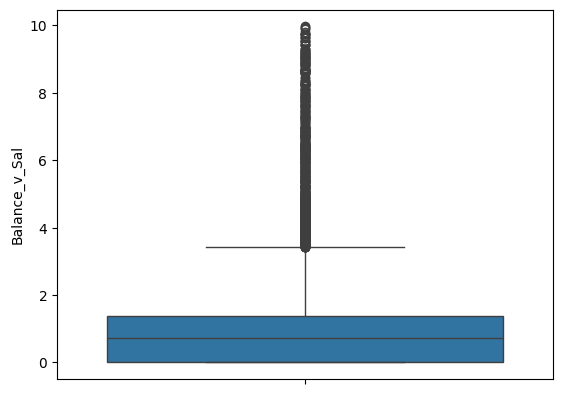

In [20]:
sns.boxplot(modelling_df.query('Balance_v_Sal < 10'), y='Balance_v_Sal')

In [21]:
modelling_df.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Balance_v_Sal
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700,3.878703
std,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769,108.337260
min,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000,0.747002
75%,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000,1.514022
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000,10614.655440


<Axes: ylabel='Balance_v_Sal'>

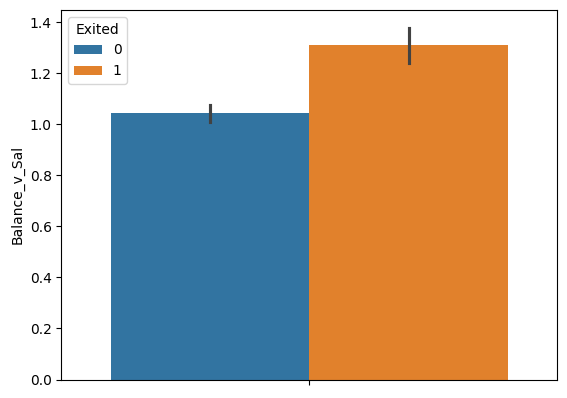

In [22]:
sns.barplot(modelling_df.query('Balance_v_Sal < 10'), y='Balance_v_Sal', hue='Exited')